In [1]:
# pip install osmnx

# Introduction
   
This notebook loads the data about planning applications, and filters it into a list of applications that are likely to be Full Planning Applications for Data Centres in London. The output of this notebook is a spreadsheet ready for manual validation and filling (there is data that needs to be manually extracted from the planning application pdfs).

The loading uses the Planning London Datahub API to acquire maximum available information, including the location. (https://www.london.gov.uk/sites/default/files/planninglondondatahub_api_connection_technical_documentation_v1.pdf)

In [2]:
import pandas as pd
from pandas import json_normalize
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

pd.set_option('display.max_columns', None)
import gzip
import time
import datetime
import ast
import requests
import json
import random

from shapely.geometry import Polygon, MultiPolygon, shape, Point, GeometryCollection
from shapely.ops import unary_union
import shapely.geometry as geom
import shapely.wkt
from shapely.ops import transform
import pyproj
# import osmnx as ox

In [3]:
pd.set_option("display.max_colwidth", 180)

In [4]:
# # ________________________________________________________________________________________________________
# # Main script for loading the planning applications data. 
# # The code is commented out as it only needs to run once. Further work is based on the output of this cell.
# # Running this cell will take a long time.
# # ________________________________________________________________________________________________________

# BASE_URL = "https://planningdata.london.gov.uk/api-guest/applications/_search"
# SCROLL_URL = "https://planningdata.london.gov.uk/api-guest/_search/scroll"

# HEADERS = {
#     "Content-Type": "application/json",
#     "X-API-AllowRequest": "be2rmRnt&"
# }

# CHUNK_SIZE = 500
# MAX_RETRIES = 5
# SLEEP_BETWEEN_CALLS = 0.15
# OUTPUT_FILE = "london_all_boroughs_applications.jsonl.gz"

# # List of London boroughs
# BOROUGHS = [
#     "Barking & Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
#     "Camden", "Croydon", "Ealing", "Enfield", "Greenwich",
#     "Hackney", "Hammersmith & Fulham", "Haringey", "Harrow", "Havering",
#     "Hillingdon", "Hounslow", "Islington", "Kensington & Chelsea", "Kingston upon Thames",
#     "Lambeth", "Lewisham", "Merton", "Newham", "Redbridge",
#     "Richmond upon Thames", "Southwark", "Sutton", "Tower Hamlets", "Waltham Forest",
#     "Wandsworth", "Westminster"
#     "Slough"
# ]

# def log(msg):
#     print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")

# def save_chunk(chunk):
#     """Write a list of application '_source' dicts to the gzip output file."""
#     with gzip.open(OUTPUT_FILE, "ab") as f:
#         for record in chunk:
#             f.write(json.dumps(record).encode("utf-8") + b"\n")

# def request_with_retries(url, payload):
#     for attempt in range(1, MAX_RETRIES + 1):
#         try:
#             response = requests.post(url, json=payload, headers=HEADERS, timeout=30)
#             if response.status_code == 200:
#                 return response.json()
#             log(f"Non-200 status {response.status_code}, attempt {attempt}")
#         except Exception as e:
#             log(f"Request error (attempt {attempt}): {e}")
#         time.sleep(1 + attempt * 0.5)
#     raise RuntimeError("Max retries reached. Scroll aborted.")

# def fetch_borough_applications(borough_name, application_type="All Other"):
#     log(f"Starting extraction for {borough_name} (application_type={application_type})")

#     # Elasticsearch query with borough and application_type filters
#     query = {
#         "size": CHUNK_SIZE,
#         "query": {
#             "bool": {
#                 "must": [
#                     {"match": {"borough": borough_name}},
#                     {"match": {"application_type": application_type}}
#                 ]
#             }
#         }
#     }

#     log("Sending initial request...")
#     init = request_with_retries(BASE_URL + "?scroll=2m", query)

#     scroll_id = init.get("_scroll_id")
#     hits = init["hits"]["hits"]
#     total_downloaded = 0

#     if hits:
#         save_chunk([h["_source"] for h in hits])
#         total_downloaded += len(hits)
#         log(f"Saved initial chunk ({len(hits)} records). Total = {total_downloaded}")

#     while True:
#         time.sleep(SLEEP_BETWEEN_CALLS)
#         payload = {"scroll": "2m", "scroll_id": scroll_id}
#         data = request_with_retries(SCROLL_URL, payload)

#         hits = data["hits"]["hits"]
#         if not hits:
#             break

#         save_chunk([h["_source"] for h in hits])
#         total_downloaded += len(hits)
#         scroll_id = data.get("_scroll_id")

#         log(f"Saved another {len(hits)}… total = {total_downloaded}")

#     log(f"Finished {borough_name}! Total records downloaded: {total_downloaded}")

# if __name__ == "__main__":
#     log("Output will be saved to: " + OUTPUT_FILE)
#     for borough in BOROUGHS:
#         fetch_borough_applications(borough)
#     log("All boroughs processed. Done.")

In [5]:
# with gzip.open(input_file, "rt", encoding="utf-8") as f_in:
#     for line in f_in:
#         record = json.loads(line)
#         break

# record
        


In [6]:
# __________________________________________________________________________________________________________________
# This code unpacks the gz file, filters for potential data centre applications, and saves the output as a dataframe.
# __________________________________________________________________________________________________________________

input_file = "london_all_boroughs_applications.jsonl.gz"
output_file = "london_all_boroughs_filtered_description.jsonl.gz"

# Keywords to include and exclude
include_keywords = [" data"]  #I am using thespace in front to exclude results where this sequence will be in the middle of the word
# exclude_keyword = "trees" #Excluding applications that are about pruning the trees

# Step 1: Filter while reading
filtered_records = []

with gzip.open(input_file, "rt", encoding="utf-8") as f_in:
    for line in f_in:
        record = json.loads(line)
        description = str(record.get("description") or "")
        
        # Include filter
        if not any(k.lower() in description.lower() for k in include_keywords):
            continue
        
        # Exclude filter
        # if exclude_keyword.lower() in description.lower():
        #     continue
        
        filtered_records.append(record)

print(f"Total filtered records: {len(filtered_records)}")

# Step 2: Load into DataFrame
df = pd.DataFrame(filtered_records)

# Step 3: Normalize nested fields
nested_cols = ["application_details", "parking_details", 
               #"decision_conditions", 
               "application_details_existing_proposed_floorspace_details"]

for col in nested_cols:
    if col in df.columns:
        nested_df = json_normalize(df[col], sep="_")
        nested_df = nested_df.add_prefix(f"{col}_")
        df = pd.concat([df.drop(columns=[col]), nested_df], axis=1)
        
print(f"Normalized DataFrame shape: {df.shape}")
df.to_csv("london_all_boroughs_filtered_description.csv", index=False)
print(f"Saved to csv.")

Total filtered records: 618
Normalized DataFrame shape: (618, 223)
Saved to csv.


# Data Cleaning

After a simple filter by " data" keyword, the dataframe requires additional cleaning.

In [7]:
cols_to_drop = [
    # "bo_system", 
    # "ward", "id", "borough", 
    # "last_updated", "last_synced", 
    "last_updated_by", 
    # "application_type", 
    "centroid_easting", "centroid_northing"]
datetime_cols = ["decision_date", "valid_date", "lapsed_date","decision_target_date"]

ldn_filtr = pd.read_csv(
    "london_all_boroughs_filtered_description.csv",
    usecols=lambda c: c not in cols_to_drop,
    parse_dates=datetime_cols,
    na_values=["NULL", "null", "None", "", "[]"],
    low_memory=False
)

In [8]:
# __________________________________________________________________________________________________________________
# As can be seen from the code below, we have a few duplicates in the dataset. 
# Id is the column that I will be using to compare the outputs
# __________________________________________________________________________________________________________________
ldn_filtr["id"].duplicated(keep=False).value_counts()

id
False    610
True       8
Name: count, dtype: int64

In [9]:
# __________________________________________________________________________________________________________________
# The columns are identical and most likely are a loading error - see last_updated column. 
# They are the same, so it is not a manual input error
# __________________________________________________________________________________________________________________
ldn_filtr[['id','last_synced','last_updated']][ldn_filtr["id"].duplicated(keep=False)].sort_values(by='id')

,id,last_synced,last_updated
511,Kingston-08_10204,2025-11-18T07:52:28.154Z,2025-08-14T13:15:53.851+01:00
539,Kingston-08_10204,2025-11-18T07:52:28.154Z,2025-08-14T13:15:53.851+01:00
512,Richmond-19_1890_DD01,2025-04-09T04:25:46.760Z,2025-03-20T12:59:32.228+00:00
536,Richmond-19_1890_DD01,2025-04-09T04:25:46.760Z,2025-03-20T12:59:32.228+00:00
514,Richmond-22_3364_DD02,2025-04-07T10:38:44.978Z,2025-03-18T23:55:42.506+00:00
538,Richmond-22_3364_DD02,2025-04-07T10:38:44.978Z,2025-03-18T23:55:42.506+00:00
513,Richmond-25_T0036_TCA,2025-04-08T07:14:31.339Z,2025-03-19T18:43:45.047+00:00
537,Richmond-25_T0036_TCA,2025-04-08T07:14:31.339Z,2025-03-19T18:43:45.047+00:00


I am trying to not drop any columns before arriving with the final set of rows.

In [10]:
# # __________________________________________________________________________________________________________________
# # I can safely drop duplicated entries
# # __________________________________________________________________________________________________________________
# ldn_filtr = ldn_filtr.drop_duplicates(subset="id")

In [11]:
# _______________________________________________________________________________________
# filtering out the PA references that cannot be found on the website, e.g. those with number-only reference. 
# Validation exercise showed that these are primarily PAs from before 2005
# ldn_filtr[ldn_filtr["lpa_app_no"] == "0101038"]
# ldn_filtr.sort_values("decision_date")["lpa_app_no"].tolist()
# _______________________________________________________________________________________
ldn_filtr = ldn_filtr[ldn_filtr["lpa_app_no"].str.contains(r"[A-Za-z\\]", na=False) == True]

ldn_filtr.shape
# the number of candidate planning applications and number of columns

(544, 220)

In [12]:
# ldn_filtr.columns.tolist()
# ldn_filtr.sort_values("decision_date")["lpa_app_no"].tolist()
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", 80)
# pd.set_option("display.width", None)
# ldn_filtr["wgs84_polygon"]

In [13]:
# _______________________________________________________________________________________________________________
# phrases to exclude if we have them in description. The phrases below are based on repetitive cleaning exercises
# _______________________________________________________________________________________________________________
remove_phrases = [
    "data cabl","data duct","Data it and Fire alarm","data and security",
    # "from data centre","from the data centre", "from a data centre", #these show change of use from data centre to something else, and we are interested in creating data centres not losing them
    "Works to trees","power and data","power & data ","power, data,","data and power","data & power",
    "data sheet","data log","Employment Data","data handling","data cabinet","datapoint","data communication",
    "level data", "financial data","tree works", "tree crown"
]
# build a single regex OR expression
pattern = "|".join(remove_phrases)

# filter out rows matching any phrase (case-insensitive)
ldn_filtr = ldn_filtr[
    ~ldn_filtr["description"].str.contains(pattern, case=False, na=False)
]

# __________________________________________________________________________________________________
# remove arboricultural planning applications. There is a specific app type that needs to be omitted
# __________________________________________________________________________________________________
ldn_filtr = ldn_filtr[
    ~ldn_filtr["application_type_full"].str.contains(
        "Tree works",
        case=False,
        na=False
    )
]

In [14]:
print(f"We are now down to {ldn_filtr.shape[0]} planning applications.")

We are now down to 488 planning applications.


On the validation stage I will be searching each planning application by the reference number, so it is important to ensure the references are showing correctly.

In [15]:
ldn_filtr["lpa_app_no"].notna().value_counts()
# checking that all applications have a number, otherwise it will not be searchable

lpa_app_no
True    488
Name: count, dtype: int64

In [16]:
ldn_filtr["lpa_app_no"].duplicated().sum()

np.int64(5)

In [17]:
ldn_filtr[ldn_filtr["lpa_app_no"].duplicated(keep=False)]

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

Seems there are a few rows that are identical, dropping these below:

In [18]:
ldn_filtr = ldn_filtr.drop_duplicates()

In [19]:
ldn_filtr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, 0 to 613
Columns: 220 entries, lpa_name to application_details_existing_proposed_floorspace_details_10
dtypes: float64(126), object(94)
memory usage: 839.1+ KB


In [20]:
# ldn_filtr.head(1)

# Detecting Core Applications (Parents)

As there can be several applications prior and following the same Full Planning Application, this can lead to double counting. I am filtering so that only Full applications are considered. However I also want to keep track of other applications that exist for the same location, because otherwise we can lose relevant amendments.

The process involves recognising the Full Planning Application, and assigning a column value based on that (it becomes a parent application). For the children (any amendments and pre-app stage), a LPA code of the parent is coded in.

In [21]:
# ldn_filtr["application_type_full"].value_counts()
# ldn_filtr[ldn_filtr["application_type_full"]=="Lawful development: Proposed use"]

In [22]:
ldn_filtr = ldn_filtr.copy()

ful_app_type = ["Full planning permission", "Full planning & listed building consent", "Lawful development: Proposed use"]
ldn_filtr["is_full_planning"] = (
    ldn_filtr["application_type_full"]
        .isin(ful_app_type)
        .where(ldn_filtr["application_type_full"].notna(), pd.NA)
)

In [23]:
#___________________________________________________________________________________
# Here I am creating an additional check to filter out applications with descriptions 
# that clearly state that the application is dependent on some other application
#___________________________________________________________________________________

# phrases to exclude if we have them in description
nonparent_phrases = [
    "pursuant", "prusuant", "persuant",
    "Request for Scoping Opinion", "Request for a Scoping Opinion", "Scoping Request under",
    "Request for Screening Opinion", "Request for a Screening Opinion", "Screening Request under",
    "Screening opinion",
    "Request for",
    "Non-material amendment", "Non material amendment", "Section 73", "Non material",
    # "Application for a Certificate of Lawful Development",
    "Details of condition",
    "Discharge of condition",
    "Variation of condition", "Deed of Variation",
    "application to vary Condition",
    "Certificate of Lawfulness of Proposed Works",
    "Notification under The Electronic Communications Code",
    "Data received",
    "Record of Data",
    "Data Condition",
    "Statement Data",
    "Request for an Environmental Impact Assessment",
    "Scoping Opinion",
    "Request for Screening Opinion"
]

# build a single regex OR expression
pattern = "|".join(nonparent_phrases)
mask_has_phrase = ldn_filtr["description"].str.contains(pattern, case=False, na=False)
ldn_filtr["is_full_planning"] = ldn_filtr["is_full_planning"].mask(mask_has_phrase, False)

In [24]:
ldn_filtr.tail(1)

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

In [25]:
print(f"We have found {ldn_filtr["is_full_planning"].isna().sum()} NA values that don't have the record of the application type. These datapoints will need to be validated manually.")
# ldn_filtr[ldn_filtr["is_full_planning"].isna()]

We have found 68 NA values that don't have the record of the application type. These datapoints will need to be validated manually.


In [26]:
#___________________________________________________________________________________
# Exporting for manual validation step 1 (performed in a separate ipynb )
#___________________________________________________________________________________

ldn_filtr.to_csv('validation_app_type_source.csv', index=False)

There were a lot of mislabeled applications from Hounslow, Tower Hamlets and Islington. I have also found some rows that don't belong to data centres at all (left as "is_full_planning" = NA). I am appending my validation results and dropping the NAs as irrelevant. I am going to use description and lpa_app_no as identifiers, because there are 5 duplicated application references in the dataset.

In [27]:
validation_app_type_output = pd.read_csv(
    "validation_app_type_output.csv", na_values=["NULL", "null", "None", "", "[]"])

In [28]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe. I am using "description" column for mapping because 
# there are 3 more duplicates with the same lpa_app_no, but different other columns.
# Then dropping NA based on the "is_full_planning" col
#___________________________________________________________________________________

# If validation has unique descriptions:
lookup = validation_app_type_output.dropna(subset=["description"]).set_index("description")["is_full_planning"]

ldn_filtr["is_full_planning"] = ldn_filtr["description"].map(lookup).combine_first(ldn_filtr["is_full_planning"])
ldn_filtr = ldn_filtr.dropna(subset=["is_full_planning"])

ldn_filtr.head(2)

,lpa_name,uprn,decision_date,epc_number,application_type_full,bo_system,id,secondary_street_name,appeal_status,postcode,appeal_decision,valid_date,reference_no_of_permission_being_relied_on,description,decision_conditions,date_building_work_started_under_previous_permission,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,locality,polygon,development_type,last_date_consultation_comments,appeal_decision_date,decision_process,decision_agency,date_building_work_completed_under_previous_permission,last_synced,site_number,application_type,actual_completion_date,title_number,actual_commencement_date,street_name,pp_id,subdivision_of_building,cil_liability,appeal_start_date,borough,decision,wgs84_polygon,application_details_affordable_housing_inlieu_payment,application_details_superseding_details,application_details_building_age,application_details_no_affordable_housing_units_provided_offsite,application_details_building_type,application_details_no_affordable_housing_units_acquired_offsite,application_details_occupation_status,application_details_scheme_name,application_details_non_permanent_dwellings_details,application_details_building_details,application_details_constraints_details,application_details_affordable_housing_fast_track,application_details_s106_agreement,application_details_air_quality_assessment,application_details_other_contributions,application_details_existing_uprns,application_details_intended_commencement_date,application_details_total_gia_existing,application_details_scheme_phasing,application_details_circular_economy_statement,application_details_commencement_notice_received,application_details_qualifying_vacant_building_floorspace,application_details_phasing_details,application_details_site_area,application_details_grey_water_reuse,application_details_surface_water_discharge_percentage_reduction,application_details_lead_registered_social_landlord,application_details_viability_assessment,application_details_overseas_company_registration_no,application_details_mayoral_cil_liability_notice_issued,application_details_intended_completion_date,application_details_projected_cost_of_works,application_details_uk_company_registration_no,application_details_internal_resi_water_usage,application_details_3d_model,application_details_transport_contributions,application_details_total_gia_gained,application_details_borough_cil_liability_notice_issued,application_details_total_gia_lost,application_details_transport_impact_assessment,application_details_social_infrastructure_contributions,application_details_rain_water_harvesting,application_details_green_suds,application_details_garden_land_lost,application_details_ownership_status,application_details_lead_developer_company_name,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_lost,application_details_other_residential_accommodation_details_other_resi_accommodation_unit_details,application_details_other_residential_accommodation_details_no_council_tax_rateable_units_gained,application_details_other_residential_accommodation_details_site_area,application_details_residential_details_affordable_percentage,application_details_residential_details_total_no_proposed_residential_units_london_shared_ownership,application_details_residential_details_total_no_proposed_residential_units_discount_market_rent,application_details_residential_details_dwelling_density,application_details_residential_details_total_no_proposed_residential_units_affordable_rent,application_details_residential_details_total_no_existing_residential_units_market_for_sale,application_details_residential_details_total_no_proposed_residential_units_market_for_sale,application_details_residential_details_total_no_existing_residential_units_london_affordable_rent,application_details_residential_details_total_no_existing_residential_units_discount_market_rent,application_details_residential_details_total_no_proposed_residential_

Now I am assuming that all full planning applications are core (parents). But it is possible that there were several full planning applications under one location, e.g. construction and subsequent alterations, or a refused application with another one approved at a later stage.

Further in this section, I am parsing the geometry from the dataframe, and evaluating locations of the parents. There is no uniform approach considering all possible reasons why there might be several parents in one place. Therefore I am preparing a validation sheet for the second round of validation.

In [29]:
# _______________________________________________________________________________________
# Code to extract geometry of the planning applications
# _______________________________________________________________________________________

# ---- PARSE CENTROIDS ----
def parse_centroid(obj):
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, str):
        try:
            return ast.literal_eval(obj)
        except Exception:
            return None
    return None

def centroid_to_point(d):
    if d is None:
        return None
    try:
        lat = float(d.get("lat"))
        lon = float(d.get("lon"))
        return Point(lon, lat)
    except Exception:
        return None

# ---- PARSE POLYGONS ----
def safe_parse(obj):
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, str):
        try:
            return ast.literal_eval(obj)
        except Exception:
            return None
    return None

def build_polygon(poly_dict):
    """Return Polygon or MultiPolygon from GeoJSON-like dict."""
    if not isinstance(poly_dict, dict):
        return None

    geom_type = poly_dict.get("type")
    coords = poly_dict.get("coordinates")

    try:
        # Polygon
        if geom_type == "Polygon" and coords:
            return Polygon(coords[0])

        # MultiPolygon
        if geom_type == "MultiPolygon" and coords:
            polygons = [Polygon(p[0]) for p in coords if p]
            return MultiPolygon(polygons) if len(polygons) > 1 else polygons[0]

        # GeometryCollection
        if geom_type.lower() == "geometrycollection":
            polygons = []
            for g in poly_dict.get("geometries", []):
                sub_geom = build_polygon(g)
                if sub_geom:
                    polygons.append(sub_geom)
            if not polygons:
                return None
            if len(polygons) == 1:
                return polygons[0]
            # Merge all polygons into MultiPolygon
            return MultiPolygon(polygons)

    except Exception:
        return None

    return None

# Transformer from WGS84 → EPSG:27700
wgs84_to_bng = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True).transform

def choose_geometry(row):
    """Return a Polygon/MultiPolygon in EPSG:27700."""
    poly = build_polygon(row.get("polygon_dict"))
    if poly and poly.is_valid:
        return poly

    # fallback: WGS84 polygon transformed
    wgs_poly = build_polygon(row.get("wgs84_polygon_dict"))
    if wgs_poly and wgs_poly.is_valid:
        try:
            return transform(wgs84_to_bng, wgs_poly)
        except Exception:
            return None

    return None

# ---- PARSE CENTROIDS ----
ldn_filtr["centroid_dict"] = ldn_filtr["centroid"].apply(parse_centroid)
ldn_filtr["geometry_point"] = ldn_filtr["centroid_dict"].apply(centroid_to_point)

# ---- PARSE POLYGONS ----
ldn_filtr["polygon_dict"] = ldn_filtr["polygon"].apply(safe_parse)
ldn_filtr["wgs84_polygon_dict"] = ldn_filtr["wgs84_polygon"].apply(safe_parse)
ldn_filtr["geometry_polygon"] = ldn_filtr.apply(choose_geometry, axis=1)

# ---- COMBINE POLYGON & CENTROID ----
ldn_filtr["geometry"] = ldn_filtr["geometry_polygon"].combine_first(ldn_filtr["geometry_point"])

# ---- CREATE GEODATAFRAME ----
ldn_filtr_gdf = gpd.GeoDataFrame(ldn_filtr, geometry="geometry", crs="EPSG:27700")

# ---- DROP UNUSED COLUMNS ----
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=[
    "centroid_dict", "polygon_dict", "wgs84_polygon_dict", "polygon", "wgs84_polygon", "geometry_polygon"
])

In [30]:
#___________________________________________________________________________________
# Find intersections between parents and subset into validation group "is_possible_child"
#___________________________________________________________________________________
# Ensure geometries exist
ldn_filtr_gdf = ldn_filtr_gdf[ldn_filtr_gdf.geometry.notna()].copy()

# Reset / create columns
ldn_filtr_gdf["is_possible_child"] = False
ldn_filtr_gdf["is_parent"] = ldn_filtr_gdf["is_full_planning"]
# Only parents
parents = ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]].copy()

# Spatial index on parents only
parents_sindex = parents.sindex

for i, (idx_parent, parent_row) in enumerate(parents.iterrows()):
    parent_geom = parent_row.geometry

    # candidate POSITIONS within `parents` (not index labels)
    cand_pos = list(parents_sindex.intersection(parent_geom.bounds))
    cand = parents.iloc[cand_pos]

    # true intersects (among parents)
    hits = cand[cand.geometry.intersects(parent_geom)]

    # drop itself
    hits = hits[hits.index != idx_parent]

    # if this parent intersects any other parent -> flag it
    if len(hits) > 0:
        ldn_filtr_gdf.loc[idx_parent, "is_possible_child"] = True

#___________________________________________________________________________________
# Clustering the possible children to see which are intersecting which
#___________________________________________________________________________________

# Start with NA for everyone
ldn_filtr_gdf["is_possible_child_cluster"] = pd.NA

# Subset: only the flagged rows
poss = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"] == True].copy()

# If 0 or 1, nothing to cluster (but you could set cluster=1 for the single row if you want)
if len(poss) <= 1:
    if len(poss) == 1:
        ldn_filtr_gdf.loc[poss.index, "is_possible_child_cluster"] = 1
else:
    # Spatial index for the small subset
    sidx = poss.sindex

    # Build adjacency list (graph)
    neighbors = {idx: set() for idx in poss.index}

    for idx, geom in poss.geometry.items():
        cand_pos = list(sidx.intersection(geom.bounds))
        cand = poss.iloc[cand_pos]

        hits = cand[cand.geometry.intersects(geom)].index
        hits = hits[hits != idx]  # exclude self

        for j in hits:
            neighbors[idx].add(j)
            neighbors[j].add(idx)  # undirected

    # Find connected components (clusters)
    visited = set()
    cluster_id = 0
    cluster_map = {}

    for start in poss.index:
        if start in visited:
            continue

        cluster_id += 1
        stack = [start]
        visited.add(start)

        while stack:
            u = stack.pop()
            cluster_map[u] = cluster_id
            for v in neighbors[u]:
                if v not in visited:
                    visited.add(v)
                    stack.append(v)

    # Write back cluster IDs only for flagged rows; everyone else stays NA
    ldn_filtr_gdf.loc[list(cluster_map.keys()), "is_possible_child_cluster"] = (
        pd.Series(cluster_map).astype("Int64")
    )

In [31]:
print(f"There are {len(ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True])} parents that need further validation.")

There are 34 parents that need further validation.


In [32]:
#___________________________________________________________________________________
# I reduce the size of the dataframe for validation
# I will need to display some columns to make a decision, and it should be only a few of them
#___________________________________________________________________________________
validation_is_true_parent = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True].copy()

# For validation, keep columns that have at least 80% non-NaN values
threshold = 0.8
min_non_na = int(threshold * len(validation_is_true_parent))
validation_is_true_parent = validation_is_true_parent.dropna(axis=1, thresh=min_non_na)

#___________________________________________________________________________________
# Exporting for manual validation step 2 (performed in a separate ipynb )
#___________________________________________________________________________________
validation_is_true_parent.to_file(
    "validation_is_true_parent_source.gpkg",
    layer="validation_is_true_parent",
    driver="GPKG"
)

In [33]:
# test = ldn_filtr_gdf[ldn_filtr_gdf["is_possible_child"]==True].copy()
# test["lpa_app_no"].duplicated().sum()

In [34]:
validation_is_true_parent_output = pd.read_csv(
    "validation_is_true_parent_output.csv", na_values=["NULL", "null", "None", "", "[]"])

#___________________________________________________________________________________
# Merging validation with the existing dataframe. Caveat is that I should have introduced uniwue keys for all applications,
# and now it is too late, so this cell contains long code tha matches both by app code and description,
# as it happens there are rows with identical descriptions and 
#___________________________________________________________________________________

# Merge validated values onto main df by BOTH keys
tmp = ldn_filtr_gdf.merge(
    validation_is_true_parent_output[["lpa_app_no", "description", "is_parent"]],
    on=["lpa_app_no", "description"],
    how="left",
    suffixes=("", "_validated")
)

# Overwrite is_parent ONLY where we have a validated value
has_val = tmp["is_parent_validated"].notna()
tmp.loc[has_val, "is_parent"] = tmp.loc[has_val, "is_parent_validated"]

# Drop helper column and put back
ldn_filtr_gdf = tmp.drop(columns=["is_parent_validated"])

In [35]:
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=["is_possible_child_cluster"])

In [36]:
ldn_filtr_gdf = ldn_filtr_gdf.drop(columns=["is_possible_child"])

In [37]:
print(f"There are {len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} parents after validation stage.")

There are 75 parents after validation stage.


# Detecting Children Applications

We need to evaluate whether other applications belong to the group of the parent full application, or are separate, for the following reasons:

- Tracking stages of the application, whether parent had any amendments that could significantly impact the parameters of our interest;
- If the full parent application was refused, is there further activity;
- The database is known to have some inconsistencies and, potentially, missing applications. If children without parents will be found, we will need to evaluate the status of the child application to see if there is a data centre there. E.g. if the child application is an amendment to the existing facility.

In [38]:
# ldn_filtr_gdf.geometry.notna().value_counts()

In [39]:
# is_child: True if is_parent is False, False if is_parent is True, NA if is_parent is NA
ldn_filtr_gdf["is_child"] = ldn_filtr_gdf["is_parent"].map({True: False, False: True}).astype("boolean")
ldn_filtr_gdf["parent_id"] = pd.NA

In [40]:
# test = ldn_filtr_gdf[
#     (ldn_filtr_gdf["is_child"] == True) &
#     (ldn_filtr_gdf["is_parent"] == True)
# ]
# len(test)

In [41]:
#___________________________________________________________________________________
# Identifying cildren overlapping parent geometry
#___________________________________________________________________________________
# Identify parent rows
parents = ldn_filtr_gdf[ldn_filtr_gdf["is_parent"].eq(True)].copy()

# Spatial index
sindex_all = ldn_filtr_gdf.sindex

for idx_parent, parent_row in parents.iterrows():
    parent_geom = parent_row.geometry
    parent_code = parent_row["id"]

    # Candidate rows based on bounding box
    possible_idx = list(sindex_all.intersection(parent_geom.bounds))
    possible_matches = ldn_filtr_gdf.iloc[possible_idx]

    # True intersection
    intersects = possible_matches[possible_matches.geometry.intersects(parent_geom)]

    # Exclude the parent itself
    intersects = intersects[intersects.index != idx_parent]

    # >>> CHANGE GOES HERE: exclude any rows that are parents (no fillna warning) <<<
    is_parent_mask = intersects["is_parent"].astype("boolean").fillna(False)
    intersects = intersects[~is_parent_mask]

    # Mark children + assign parent
    ldn_filtr_gdf.loc[intersects.index, "is_child"] = True
    ldn_filtr_gdf.loc[intersects.index, "parent_id"] = parent_code

In [42]:
# test = ldn_filtr_gdf[
#     (ldn_filtr_gdf["is_child"] == True) &
#     (ldn_filtr_gdf["is_parent"] == True)
# ]
# len(test)

In [43]:
#___________________________________________________________________________________
# Function to group find parent and its children
#___________________________________________________________________________________

def pick_parent_and_children(subset):
    """Randomly select parent & children — fallback to point geometry if needed."""
    parent = parents.sample(1).iloc[0]
    parent_code = parent["id"]

    children = subset[subset["parent_id"] == parent_code]

    return parent, children

The children overlapping the parents cound be viewed using the code below:

In [44]:
# # Get a random parent set
# parent_row, children = pick_parent_and_children(ldn_filtr_gdf)
# parent_code = parent_row["id"]

# # Build combined dataset (safe when children is empty)
# parent_df = parent_row.to_frame().T

# parts = [parent_df]
# if children is not None and not children.empty:
#     parts.append(children.reindex(columns=parent_df.columns))

# to_plot = pd.concat(parts, axis=0)
# to_plot = gpd.GeoDataFrame(to_plot, geometry="geometry", crs=ldn_filtr_gdf.crs)

# # Reproject to Web Mercator
# to_plot_web = to_plot.to_crs(3857)

# # Split into geometry types
# poly_mask = to_plot_web.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
# point_mask = to_plot_web.geometry.geom_type == "Point"

# parent_poly = to_plot_web[(poly_mask) & (to_plot_web["id"] == parent_code)]
# parent_point = to_plot_web[(point_mask) & (to_plot_web["id"] == parent_code)]

# children_poly = to_plot_web[(poly_mask) & (to_plot_web["id"] != parent_code)]
# children_point = to_plot_web[(point_mask) & (to_plot_web["id"] != parent_code)]

# fig, ax = plt.subplots(figsize=(10, 10))

# # Children polygons
# if not children_poly.empty:
#     children_poly.plot(
#         ax=ax, alpha=0.5, edgecolor="black", facecolor="lightblue"
#     )

# # Children points
# if not children_point.empty:
#     children_point.plot(
#         ax=ax, color="blue", markersize=50, alpha=0.3
#     )

# # Parent polygon (highlighted)
# if not parent_poly.empty:
#     parent_poly.plot(
#         ax=ax, alpha=0.4, edgecolor="red", facecolor="yellow"
#     )

# # Parent point (highlighted)
# if not parent_point.empty:
#     parent_point.plot(
#         ax=ax, color="red", markersize=80
#     )

# # Always plot centroid so parent is visible
# parent_centroid = parent_row.geometry.centroid
# gpd.GeoSeries([parent_centroid], crs=ldn_filtr_gdf.crs).to_crs(3857).plot(
#     ax=ax, color="red", markersize=200, zorder=20
# )

# # Auto fit
# minx, miny, maxx, maxy = to_plot_web.total_bounds
# buffer = 100   # smaller buffer for tiny polygons
# ax.set_xlim(minx - buffer, maxx + buffer)
# ax.set_ylim(miny - buffer, maxy + buffer)

# #  add basemap after setting limits
# ctx.add_basemap(
#     ax,
#     crs=to_plot_web.crs,
#     source=ctx.providers.CartoDB.Positron,
#     zoom=18   # safe maximum for this provider
# )

# geom_display = parent_poly.geometry.values if not parent_poly.empty else parent_point.geometry.values

# ax.set_title(
#     f"Parent (red dot) + Children (polygons) \n"
#     f"Parent code: {parent_code}\n",
#     # f"Parent geom: {geom_display}",
#     fontsize=14
# )

# ax.set_axis_off()
# plt.show()

In [45]:
# ldn_filtr_gdf[ldn_filtr_gdf["uid"]==325]

In [46]:
print(f"There are {ldn_filtr_gdf["parent_id"].isna().sum() - len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} children that don't belong to any parent (orphans). Eiter they are all pre-apps, or indicate missing data.")

There are 160 children that don't belong to any parent (orphans). Eiter they are all pre-apps, or indicate missing data.


In [47]:
#___________________________________________________________________________________
# Let's group the children
#___________________________________________________________________________________

ldn_filtr_gdf["child_group"] = pd.NA

mask_has_parent = ldn_filtr_gdf["parent_id"].notna()

# assign group numbers for each parent_id (start at 1)
ldn_filtr_gdf.loc[mask_has_parent, "child_group"] = (
    ldn_filtr_gdf.loc[mask_has_parent].groupby("parent_id", sort=False).ngroup() + 1
    ).astype("Int64")  # nullable integer

In [48]:
#___________________________________________________________________________________
# Find groups without parent, or individual applications
#___________________________________________________________________________________

# Orphans: children that still have no group
orph_mask = (ldn_filtr_gdf["is_parent"] == False) & (ldn_filtr_gdf["child_group"].isna())
orphans = ldn_filtr_gdf.loc[orph_mask].copy()

if not orphans.empty:
    # spatial index on orphans
    sidx = orphans.sindex
    orphan_idx = list(orphans.index)

    # union-find (disjoint set)
    parent = {i: i for i in orphan_idx}
    rank = {i: 0 for i in orphan_idx}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    # build unions by intersects
    for i, geom in zip(orphans.index, orphans.geometry):
        # candidates by bbox
        cand_pos = list(sidx.intersection(geom.bounds))
        if not cand_pos:
            continue
        cand = orphans.iloc[cand_pos]
        # real intersects
        hits = cand[cand.geometry.intersects(geom)]
        for j in hits.index:
            if j != i:
                union(i, j)

    # map root -> component members
    comp = {}
    for i in orphan_idx:
        r = find(i)
        comp.setdefault(r, []).append(i)

    # next available group number (don’t reuse)
    existing_max = ldn_filtr_gdf["child_group"].max()
    next_group = int(existing_max) + 1 if pd.notna(existing_max) else 1

    # assign a new group id per component
    # only for components with more than one member (real groups)
    for _, members in comp.items():
        if len(members) <= 1:
            continue  # leave standalone orphans with child_group = NaN
        ldn_filtr_gdf.loc[members, "child_group"] = next_group
        next_group += 1

    # keep nullable int dtype
    ldn_filtr_gdf["child_group"] = ldn_filtr_gdf["child_group"].astype("Int64")

In [49]:
ldn_filtr_gdf["is_orphan"] = (
    (ldn_filtr_gdf["is_parent"] == False) &
    (ldn_filtr_gdf["parent_id"].isna())
)

In [50]:
ldn_filtr_gdf["is_orphan"].value_counts()

is_orphan
False    319
True     160
Name: count, dtype: int64

In [51]:
print(f"There are {ldn_filtr_gdf["child_group"].isna().sum() - len(ldn_filtr_gdf[ldn_filtr_gdf["is_parent"]==True])} orphans that are not part of any group.")

There are 61 orphans that are not part of any group.


In [52]:
#___________________________________________________________________________________
# I reduce the size of the dataframe for validation
#___________________________________________________________________________________
validation_is_informative_orphan = ldn_filtr_gdf[ldn_filtr_gdf["is_orphan"] == True].copy()

# For validation, keep columns that have at least 50% non-NaN values
threshold = 0.5
min_non_na = int(threshold * len(validation_is_informative_orphan))
validation_is_informative_orphan = validation_is_informative_orphan.dropna(axis=1, thresh=min_non_na)

#___________________________________________________________________________________
# Exporting for manual validation step 3 (performed in a separate ipynb )
#___________________________________________________________________________________
validation_is_informative_orphan.to_file(
    "validation_is_informative_orphan_source.gpkg",
    layer="validation_is_informative_orphan",
    driver="GPKG"
)

The validation revealed that a few orphans were in fact belonging to one of the parents, but were not matched initially due to incorrect geometry data. Since we are interested in parents, these orphans were not matched to them to reduce the workload.

In [53]:
validation_is_informative_orphan = pd.read_csv(
    "validation_is_informative_orphan_output.csv", na_values=["NULL", "null", "None", "", "[]"])

In [54]:
# validation_is_informative_orphan.info()

In [55]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe by id
#___________________________________________________________________________________

# Merge validated values onto main df by BOTH keys
tmp = ldn_filtr_gdf.merge(
    validation_is_informative_orphan[["id", "useful_orphan"]].rename(columns={"useful_orphan": "useful_orphan_validated"}),
    on="id",
    how="left",
)

has_val = tmp["useful_orphan_validated"].notna()
tmp.loc[has_val, "useful_orphan"] = tmp.loc[has_val, "useful_orphan_validated"]

ldn_filtr_gdf = tmp.drop(columns=["useful_orphan_validated"])

In [56]:
ldn_filtr_gdf["useful_orphan"].value_counts()

useful_orphan
False    149
True       7
Name: count, dtype: int64

# Exporting for the manual input stage

At this stage I take a subset of the filtered dataframe that includes only full planning applications for the data centres, and several other applications that could point to the existing data centres. I analyse the utilisation of the initial column set, and remove those that have high % of NA results.

Finally, I make an export of the reduced dataframe to proceed with the manual lookup on the planning portals.

In [57]:
ldn_ful_gdf = ldn_filtr_gdf[(ldn_filtr_gdf["useful_orphan"] == True) | (ldn_filtr_gdf["is_parent"] == True)].copy()

In [58]:
cols_to_merge = [
    f"application_details_existing_proposed_floorspace_details_{i}" for i in range(11)
] #these columns i need to preserve

# Create a new column with list of values
ldn_ful_gdf["floorspace_details_combined"] = ldn_ful_gdf[cols_to_merge].values.tolist()

# Drop the original columns from the filtered DataFrame
ldn_ful_gdf = ldn_ful_gdf.drop(columns=cols_to_merge)

ldn_ful_gdf = ldn_ful_gdf.drop(
    columns=[col for col in ldn_ful_gdf.columns if col.startswith("application_details_residential_")]
) #these columns are mostly null or 0

In [59]:
ldn_ful_gdf.shape

(82, 177)

In [60]:
pd.set_option('display.max_rows', 500)

In [61]:
ldn_ful_gdf.isna().sum().sort_values()

lpa_name                                                                                              0
is_orphan                                                                                             0
is_child                                                                                              0
is_parent                                                                                             0
geometry                                                                                              0
geometry_point                                                                                        0
is_full_planning                                                                                      0
borough                                                                                               0
application_type                                                                                      0
last_synced                                                     

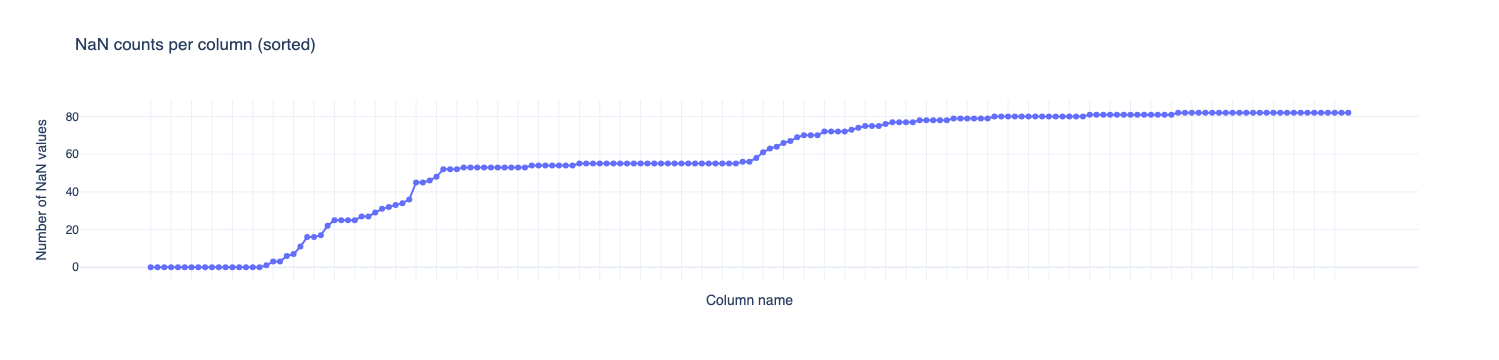

In [62]:
import plotly.express as px

s = ldn_ful_gdf.isna().sum().sort_values()

# Convert to DataFrame
df_nan = pd.DataFrame({
    "Column": s.index,
    "NaN Count": s.values
})

fig = px.line(
    df_nan,
    x="Column",
    y="NaN Count",
    labels={"Column": "Column name", "NaN Count": "Number of NaN values"},
    title="NaN counts per column (sorted)"
)

fig.update_traces(mode="lines+markers")

# Hide x-axis tick labels
fig.update_layout(
    xaxis=dict(showticklabels=False),
    template="plotly_white"
)

fig.show()

In [63]:
56 / (len(ldn_ful_gdf)/100)

68.29268292682927

In [64]:
#_____________________________________________________________________________________________________________________
# I reduce the size of the dataframe using the chart above as a guide
#_____________________________________________________________________________________________________________________

# threshold = 1 - 56 / (len(ldn_ful_gdf)/100)
# min_non_na = int(threshold * len(ldn_ful_gdf))
min_non_na = 32

ldn_ful_gdf = ldn_ful_gdf.dropna(axis=1, thresh=min_non_na)

# # List of columns exempt from being dropped
# exempt_cols = ["url_planning_app", ]  # example list

# # Columns that would be dropped by dropna
# cols_to_drop = [
#     col for col in ldn_ful_gdf.columns
#     if col not in exempt_cols and ldn_ful_gdf[col].count() < min_non_na
# ]

In [65]:
ldn_ful_gdf.shape

(82, 43)

In [66]:
ldn_ful_gdf.head(10)

,lpa_name,uprn,decision_date,application_type_full,bo_system,id,postcode,valid_date,description,last_updated,ward,lapsed_date,decision_target_date,centroid,lpa_app_no,status,site_name,url_planning_app,development_type,decision_process,decision_agency,last_synced,site_number,application_type,street_name,pp_id,cil_liability,borough,decision,application_details_building_details,application_details_site_area,application_details_non_residential_details_site_area,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost,application_details_non_residential_details_total_gia_gained,application_details_non_residential_details_total_gia_lost,application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained,is_full_planning,geometry_point,geometry,is_parent,is_child,is_orphan,floorspace_details_combined
0,Barking & Dagenham,100101450,12/09/2018,Full planning permission,Idox Tascomi,Barking_&_Dagenham-18_00161_FUL,NaN,05/02/2018,"Erection of two data centre buildings (Use Class B8), with ancillary plant, offices, gatehouse, electrical sub-stations, fuel storage, car parking, site fencing, landscaping an...",2025-03-20T18:57:14.569+00:00,Eastbrook,12/09/2023,07/05/2018,"{'lat': 49.766807, 'lon': -7.55716}",18/00161/FUL,Lapsed,London East Business And Technical Park,https://online-befirst.lbbd.gov.uk/planning/index.html?fa=getApplication&id=15772,Major offices-R and D-light industry,Committee,NaN,2025-04-09T06:10:28.578Z,NaN,All Other,YEWTREE AVENUE,NaN,True,London Borough of Barking and Dagenham,Approved,NaN,0.0000,NaN,0.0,0.0,0.0,52797.0,True,POINT (-7.55716 49.766807),"POLYGON ((550745 185653.291, 550760.214 185448.365, 550779.396 185449.026, 550847.408 185454.318, 550878.496 185460.932, 550905.616 185460.932, 550943.981 185464.24, 550985.653...",True,False,False,"[{'gia_existing': -1, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B2', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no':..."
12,Bexley,010011862607,02/10/2023,Full planning permission,Idox Uniform,Bexley-23_00960_FUL,DA8 1EW,27/04/2023,"Installation of 8 new dry coolers, a generator, transformer, plant container and associated works and pond to the existing data centre.",2025-03-19T22:26:55.098+00:00,ERITHN,02/10/2026,22/06/2023,"{'lat': 51.4915, 'lon': 0.166692}",23/00960/FUL,Approved,Unit 8,NaN,NaN,NaN,NaN,2025-04-09T04:22:46.653Z,NaN,All Other,Viking Way,PP-12028698,False,London Borough of Bexley,Approved,NaN,0.0300,NaN,0.0,0.0,0.0,0.0,True,POINT (0.166692 51.4915),"POLYGON ((550516.58 179177.444, 550516.599 179174.439, 550513.545 179174.349, 550513.595 179177.355, 550516.58 179177.444))",True,False,False,"[{'gia_existing': 4104, 'superseded_date': None, 'actual_completion_date': None, 'use_class': 'B8', 'gia_gained': 0, 'actual_commencement_date': None, 'superseded_by_lpa_app_no..."
20,Bromley,010003628052,03/04/2020,NaN,Idox Uniform,Bromley-19_04182_FULL1,BR5 2UB,25/11/2019,Alterations and additions to existing building including replacement roof and wall cladding to facilitate a data/records processing/management centre (Mixed Use Class B1/B2/B8)...,2025-03-21T01:29:34.314+00:00,CRAYVE,03/04/2023,20/01/2020,"{'lon': '0.10776809999999999', 'lat': '51.3927088'}",19/04182/FULL1,Approved,Stanbridge Limited,NaN,NaN,Delegated,NaN,2025-04-09T05:07:18.438Z,NaN,All Other,Cray Valley Road,PP-08130427,False,LB Bromley,Approved,NaN,0.1490,NaN,NaN,NaN,NaN,NaN,True,POINT (0.1077681 51.3927088),"POLYGON ((546740.4 168042.85, 546736.5 168041.45, 546732.4 168053.65, 546730.9 168058.05, 546727.4 168068.6, 546727.3 168068.9, 546727.15 168069.35, 546725.2 168071.2, 546723.8...",True,False,False,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]"
22,Camden,5057038,23/07/2012,Full planning permission,Northgate M3,Camden-2012_2752_P,NW1 8QU,30/05/2012,Use of ground floor retail unit (Class A1) as an internet cafe and data-controlled administrative booking office fo

In [67]:
#___________________________________________________________________________________
# Exporting for manual fill in. I am dropping the geometry and helper columns
#___________________________________________________________________________________

ldn_ful_gdf_essential = ldn_ful_gdf.drop(axis=1, columns=["bo_system", "centroid","pp_id", "geometry_point",
                                                          "geometry",
                                                          "is_parent", "is_child", 
                                                          "is_orphan" 
                                                         ])

ldn_ful_gdf_essential.to_csv("ldn_ful_gdf_essential.csv", index=False)

In [68]:
ldn_ful_gdf_essential_ed1 = pd.read_csv(
    "ldn_ful_gdf_essential_ed2.csv", na_values=["NaN","NULL", "null", "None", "", "[]"])

In [69]:
#___________________________________________________________________________________
# Merging validation with the existing dataframe by id
#___________________________________________________________________________________
# Outer merge to include all rows from both DataFrames
merged = ldn_ful_gdf.merge(
    ldn_ful_gdf_essential_ed1,
    on="id",
    how="outer",
    suffixes=("", "_essential")
)

# For columns present in both but potentially conflicting, prefer values from the essential dataset
# Loop through essential columns (excluding 'id'), and overwrite if the '_essential' version exists
for col in ldn_ful_gdf_essential_ed1.columns:
    if col != "id" and f"{col}_essential" in merged.columns:
        merged[col] = merged[f"{col}_essential"].combine_first(merged[col])
        merged.drop(columns=[f"{col}_essential"], inplace=True)

# Final result: overwrite + additional rows added
ldn_ful_gdf = merged

In [70]:
# -----------------------------------------------------------------------------------
# 1) Fill geometry_point from Easting/Northing (EPSG:27700 -> EPSG:4326)
# -----------------------------------------------------------------------------------
mask_en = ldn_ful_gdf["Easting"].notna() & ldn_ful_gdf["Northing"].notna()

# create points in EPSG:27700
ldn_ful_gdf.loc[mask_en, "geometry_point"] = [
    Point(xy) for xy in zip(ldn_ful_gdf.loc[mask_en, "Easting"],
                            ldn_ful_gdf.loc[mask_en, "Northing"])
]

tmp = gpd.GeoDataFrame(
    ldn_ful_gdf.loc[mask_en].copy(),
    geometry="geometry_point",
    crs="EPSG:27700"
).to_crs("EPSG:4326")

ldn_ful_gdf.loc[mask_en, "geometry_point"] = tmp.geometry.values


# -----------------------------------------------------------------------------------
# 2) If still NaN, fill from geometry_polygon centroid
# -----------------------------------------------------------------------------------
mask_missing = ldn_ful_gdf["geometry_point"].isna() & ldn_ful_gdf["geometry"].notna()

# make a temporary GeoDataFrame using geometry_polygon
tmp_poly = gpd.GeoDataFrame(
    ldn_ful_gdf.loc[mask_missing].copy(),
    geometry="geometry",
    crs="EPSG:27700"   # <- change this if your polygons are not 4326
)

# centroid (lon/lat point)
ldn_ful_gdf.loc[mask_missing, "geometry_point"] = tmp_poly.geometry.centroid.values.to_crs("EPSG:4326")

In [71]:
#___________________________________________________________________________________
# Dropping intermediate columns
#___________________________________________________________________________________
ldn_ful_gdf = ldn_ful_gdf.drop(axis=1, columns=[
    'valid_date','ward','lapsed_date','decision_target_date','bo_system','application_type_full',
    'status', 'site_name','development_type','decision_process','decision_agency',
    'last_synced','site_number','application_type','street_name','pp_id','cil_liability','borough','decision',
    'application_details_building_details','application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_lost',
    'application_details_non_residential_details_total_gia_gained','application_details_non_residential_details_total_gia_lost',
    'application_details_non_residential_details_total_non_resi_gross_internal_floor_area_to_be_gained',
    "application_details_non_residential_details_site_area", "SIL",
    # 'is_full_planning', 
    'floorspace_details_combined','Google', 'centroid',
    'is_parent',
    'is_child','is_orphan', 
    'Easting', 'Northing'
])

In [72]:
#___________________________________________________________________________________
# Dropping rows that didn't pass validation
#___________________________________________________________________________________
ldn_ful_gdf = ldn_ful_gdf[ldn_ful_gdf["action"] != "remove"].drop(axis=1, columns=['action'])
# ldn_ful_gdf = ldn_ful_gdf.drop(axis=1, columns=['action'])

#___________________________________________________________________________________
# unifying the column names in case we added more on validation
#___________________________________________________________________________________
ldn_ful_gdf.columns = ldn_ful_gdf.columns.str.lower()

In [73]:
ldn_ful_gdf[ldn_ful_gdf['geometry_point'].isna()]

,lpa_name,uprn,decision_date,id,postcode,description,last_updated,lpa_app_no,url_planning_app,application_details_site_area,is_full_planning,geometry_point,geometry,notes,enterprise,current_occupier,website,address,completed,data_centre_since,preapp_started,b8_no_storeys,b8_max_height_m,b8_gia_sqm,other_use_classes_present_within_b8_building,b8_total_staff_fte,utility_total_electr_capacity_mva,it_load_capacity_mw,density_kw_max_per_sqm,pue,tier,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate


In [74]:
numeric_cols = ['application_details_site_area', 'data_centre_since', 
                # 'preapp_started', LEAVING THIS FOR LATER
 # 'application_details_non_residential_details_site_area',
                'b8_no_storeys','b8_max_height_m','b8_gia_sqm','b8_total_staff_fte','security_staff','site_engineers_staff','managers_staff','cleaners_staff','visitor_staff_not_on_site','cluster_staff_not_on_site','b8_employees_at_a_day_reported', 'b8_employees_at_a_day_estimate',
               'total/day ratio']

for col in numeric_cols:
    ldn_ful_gdf[col] = pd.to_numeric(ldn_ful_gdf[col], errors='raise')

# ldn_ful_gdf["data_centre_since"] = pd.to_datetime(ldn_ful_gdf["data_centre_since"], format="%Y", errors="coerce")
# ldn_ful_gdf["preapp_started"] = pd.to_datetime(ldn_ful_gdf["preapp_started"], format="%Y", errors="coerce")

boolean_cols = [
    "enterprise"
]
# Convert to boolean (non-null & truthy values become True, else False)
for col in boolean_cols:
    ldn_ful_gdf[col] = ldn_ful_gdf[col].astype(bool)

In [75]:
# ldn_ful_gdf.head(3)

In [76]:
# ldn_ful_gdf

In [77]:
ldn_ful_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 69 entries, 0 to 112
Data columns (total 40 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   lpa_name                                      69 non-null     object  
 1   uprn                                          36 non-null     object  
 2   decision_date                                 55 non-null     object  
 3   id                                            59 non-null     object  
 4   postcode                                      58 non-null     object  
 5   description                                   58 non-null     object  
 6   last_updated                                  43 non-null     object  
 7   lpa_app_no                                    64 non-null     object  
 8   url_planning_app                              62 non-null     object  
 9   application_details_site_area                 60 non

In [78]:
ldn_ful_gdf.to_csv("final_output.csv", index=False)

In [79]:
len(ldn_ful_gdf)

69

# END

In [80]:
# # Suppose ldn_filtr_gdf is your GeoDataFrame, with centroid points already as geometry (in WGS84)
# ldn_centroids = ldn_filtr_gdf.copy()
# ldn_centroids = ldn_centroids.to_crs("EPSG:4326")

# tags = {"building": True}

# def fetch_buildings_around(lat, lon, dist=50):
#     """Fetch building footprints within `dist` metres of (lat, lon)."""
#     return ox.features_from_point((lat, lon), tags, dist=dist)

# all_buildings = []

# total = len(ldn_centroids)
# print(f"Starting OSM fetch for {total} centroids...")

# for i, (idx, row) in enumerate(ldn_centroids.iterrows(), 1):
#     print(f"\n[{i}/{total}] Processing lpa_app_no={row['lpa_app_no']} (index {idx})")

#     geom = row["geometry_point"]  # your actual centroid column
#     if geom is None:
#         print(" → No geometry, skipping.")
#         continue

#     lat, lon = geom.y, geom.x

#     try:
#         print(" → Fetching buildings from OSM...")
#         b = fetch_buildings_around(lat, lon, dist=50)

#         print(f" → Found {len(b)} buildings")
#         b["lpa_app_no"] = row["lpa_app_no"]
#         all_buildings.append(b)

#     except Exception as e:
#         print(f" → Error fetching for {row['lpa_app_no']}: {e}")

# print("\nOSM fetch complete.")
# print(f"Total building GeoDataFrames fetched: {len(all_buildings)}")

In [81]:
# # Combine into one GeoDataFrame
# if all_buildings:
#     buildings_gdf = gpd.GeoDataFrame(pd.concat(all_buildings, ignore_index=True), crs=all_buildings[0].crs)
# else:
#     buildings_gdf = gpd.GeoDataFrame(columns=["lpa_app_no", "geometry"], crs="EPSG:4326")

# # Optionally convert to British National Grid
# buildings_gdf = buildings_gdf.to_crs("EPSG:27700")

# # print(buildings_gdf.head())

In [82]:
# buildings_gdf.to_file("buildings_osm.gpkg", layer="buildings_osm", driver="GPKG")

In [83]:
# # Use the geometry_point column
# points_gdf = ldn_filtr_gdf.set_geometry("geometry_point")

# # Perform spatial join: points that intersect any building
# joined = gpd.sjoin(points_gdf, buildings_gdf, how="left", predicate="intersects")

# # Each point may have multiple rows if it intersects multiple buildings
# # Group by original point index, mark True if any intersection exists
# built_up_series = joined.groupby(joined.index).apply(lambda g: g["index_right"].notna().any())

# # Assign back to the points GeoDataFrame
# points_gdf["built_up"] = built_up_series

# # Copy back to original
# ldn_filtr_gdf["built_up"] = points_gdf["built_up"]

# print(ldn_filtr_gdf[["lpa_app_no", "built_up"]].head())

In [84]:
# ldn_filtr_gdf.to_file("ldn_filtr_gdf.gpkg", layer="ldn_data", driver="GPKG")

In [85]:
# # Keep columns that have at least 40% non-NaN values
# threshold = 0.4  # 10% non-NaN required
# min_non_na = int(threshold * len(ldn_filtr))

# ldn_filtr = ldn_filtr.dropna(axis=1, thresh=min_non_na)

In [86]:
# import plotly.express as px

# # Ensure we have a GeoDataFrame with WGS84 coordinates for plotting
# ldn_plot_gdf = ldn_filtr_gdf.to_crs("EPSG:4326")

# # Extract lat/lon from geometry_point
# ldn_plot_gdf["lon"] = ldn_plot_gdf["geometry_point"].x
# ldn_plot_gdf["lat"] = ldn_plot_gdf["geometry_point"].y

# # Create interactive scatter map using the new scatter_map
# fig = px.scatter_map(
#     ldn_plot_gdf,
#     lat="lat",
#     lon="lon",
#     color="built_up",
#     hover_name="lpa_app_no",
#     hover_data={"lat": True, "lon": True, "built_up": True},
#     color_discrete_map={True: "red", False: "blue"},
#     zoom=12,
#     height=600,
# )

# # # Use an open-source MapLibre style
# # fig.update_layout(mapbox_style="open-street-map")
# # fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# fig.show()